# Загрузка датасета

In [101]:
import time


Загрузка датасета в PyTorch — через torchvision.


In [102]:
# импорт необходимых библиотек для PyTorch
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


# определяем преобразования для изображений
transform = transforms.Compose([
    transforms.ToTensor(),                           # PIL → тензор, значения [0, 1]
    transforms.Lambda(lambda x: x.view(-1))          # (1,28,28) → (784)
])


# загрузка обучающей выборки
full_train = datasets.EMNIST(
    root='./data',           # папка для сохранения данных
    split='letters',         # буквенный датасет (не digits или balanced)
    train=True,              # обучающая выборка
    download=True,           # скачать, если нет локально
    transform=transform      # применяем преобразования
)


# загрузка тестовой выборки
test_dataset = datasets.EMNIST(
    root='./data',
    split='letters',
    train=False,             # тестовая выборка
    download=True,
    transform=transform
)

# === ИСПРАВЛЕНИЕ МЕТОК ДЛЯ PYTORCH ===
# full_train.targets = full_train.targets - 1
# 00test_dataset.targets = test_dataset.targets - 1

print(f"Размер полной обучающей выборки: {len(full_train)}")
print(f"Размер оригинальной тестовой выборки: {len(test_dataset)}")

Размер полной обучающей выборки: 124800
Размер оригинальной тестовой выборки: 20800


In [103]:
full_train.targets.unique()

tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
        19, 20, 21, 22, 23, 24, 25, 26])

Загрузка датасета в TensorFlow — через конвертацию из PyTorch.


In [104]:
import tensorflow as tf
import numpy as np


# получение данных из PyTorch
X_train = full_train.data.numpy().reshape(-1, 784).astype('float32') / 255.0
y_train = full_train.targets.numpy().astype('int32') - 1


X_test = test_dataset.data.numpy().reshape(-1, 784).astype('float32') / 255.0
y_test = test_dataset.targets.numpy().astype('int32') - 1


print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")


# создание tf.data.Dataset
BATCH_SIZE = 64
tf_train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
tf_train_dataset = tf_train_dataset.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


tf_test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
tf_test_dataset = tf_test_dataset.batch(BATCH_SIZE)

X_train: (124800, 784), y_train: (124800,)
X_test: (20800, 784), y_test: (20800,)


In [105]:
test_dataset_tf = tf_test_dataset

# 🔍 EDA и разбиение на train / val


In [106]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import tensorflow as tf

# === Фиксация random seed ===
torch.manual_seed(42)
tf.random.set_seed(42)
np.random.seed(42)

# === 1. Общая информация ===
print("=== Общая информация ===")
print(f"Размер полной обучающей выборки: {len(full_train)}")
print(f"Размер тестовой выборки: {len(test_dataset)}")
print(f"Форма одного изображения (после преобразования): {full_train[0][0].shape}")
print(f"Тип метки: {type(full_train[0][1])}, диапазон меток (до коррекции): [{min(full_train.targets)}, {max(full_train.targets)}]")
print(f"После коррекции (y - 1): [{y_train.min()}, {y_train.max()}]")

=== Общая информация ===
Размер полной обучающей выборки: 124800
Размер тестовой выборки: 20800
Форма одного изображения (после преобразования): torch.Size([784])
Тип метки: <class 'int'>, диапазон меток (до коррекции): [1, 26]
После коррекции (y - 1): [0, 25]


In [107]:
# Пример диапазона пикселей
sample_img = full_train[0][0].numpy()
print(f"Диапазон значений пикселей: [{sample_img.min():.3f}, {sample_img.max():.3f}]")
assert 0 <= sample_img.min() <= sample_img.max() <= 1, "Пиксели не в [0, 1]!"

Диапазон значений пикселей: [0.000, 1.000]


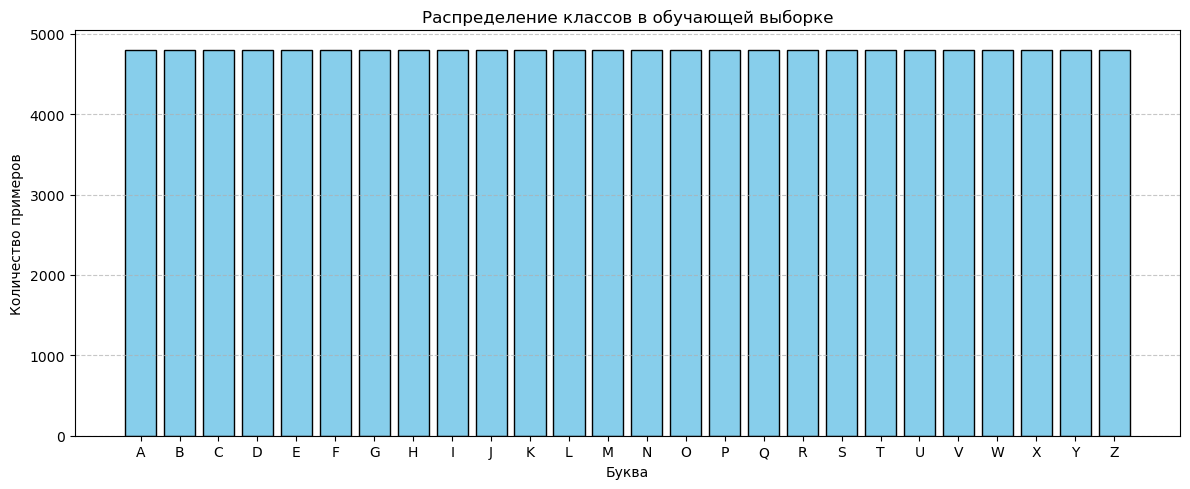


Минимум: 4800, Максимум: 4800
✅ Датасет сбалансирован.


In [108]:
# === 2. Гистограмма распределения классов ===
plt.figure(figsize=(12, 5))
plt.hist(y_train, bins=np.arange(27)-0.5, rwidth=0.8, color='skyblue', edgecolor='black')
plt.xticks(ticks=np.arange(26), labels=[chr(i) for i in range(ord('A'), ord('Z') +1)])
plt.title("Распределение классов в обучающей выборке")
plt.xlabel("Буква")
plt.ylabel("Количество примеров")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Вывод по сбалансированности
unique, counts = np.unique(y_train, return_counts=True)
print(f"\nМинимум: {counts.min()}, Максимум: {counts.max()}")
if counts.max() - counts.min() <= 10:
    print("✅ Датасет сбалансирован.")
else:
    print("⚠️ Датасет несбалансирован.")

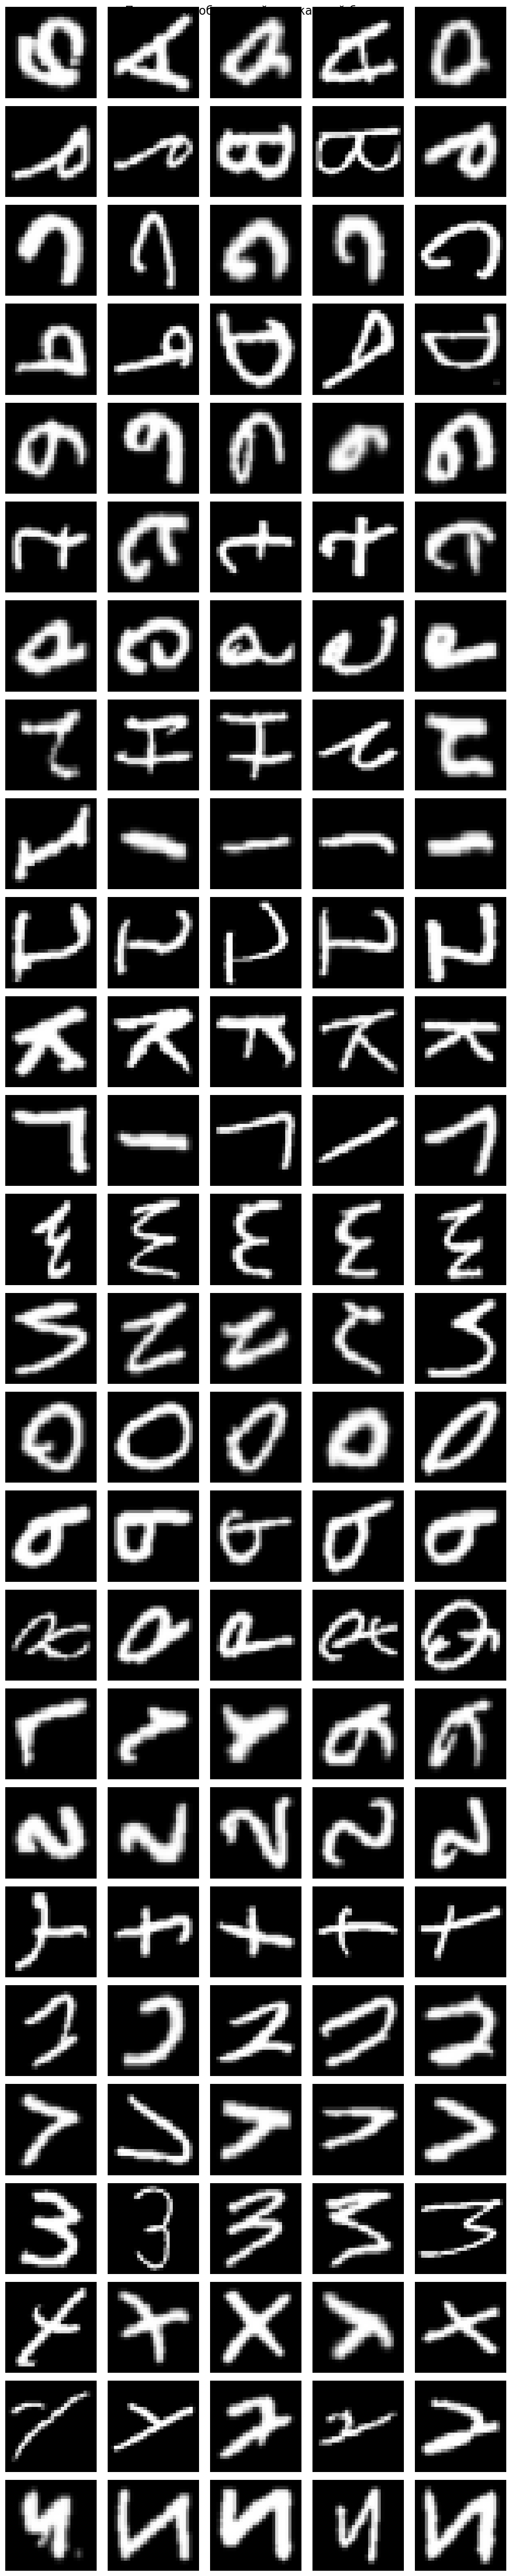

In [109]:
# === 3. Визуализация 5 случайных примеров на каждую букву ===
fig, axes = plt.subplots(26, 5, figsize=(10, 50))
for class_idx in range(26):
    # Находим индексы всех примеров этого класса
    indices = np.where(y_train == class_idx)[0]
    selected = np.random.choice(indices, size=5, replace=False)
    for j, idx in enumerate(selected):
        img = X_train[idx].reshape(28, 28)
        axes[class_idx, j].imshow(img, cmap='gray')
        axes[class_idx, j].axis('off')
    axes[class_idx, 0].set_ylabel(chr(ord('A') + class_idx), rotation=0, size='large', labelpad=20)
plt.suptitle("Примеры изображений для каждой буквы", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

In [110]:
# --- ИСПРАВЛЕНИЕ МЕТОК ДЛЯ PYTORCH-ДАТАСЕТОВ ---
full_train.targets = full_train.targets - 1
test_dataset.targets = test_dataset.targets - 1

print("Метки скорректированы: теперь в диапазоне 0–25")

Метки скорректированы: теперь в диапазоне 0–25


In [111]:
#  Конвертация в NumPy и разбиение
X_train = full_train.data.numpy().reshape(-1, 784).astype('float32') / 255.0
y_train = full_train.targets.numpy().astype('int32')  # уже 0–25

X_test = test_dataset.data.numpy().reshape(-1, 784).astype('float32') / 255.0
y_test = test_dataset.targets.numpy().astype('int32')

# ... дальше разбиение на train/val ...

In [112]:
# === 4. Разбиение на train / val (PyTorch) ===
train_size = int(0.9 * len(full_train))
val_size = len(full_train) - train_size
train_dataset_pt, val_dataset_pt = random_split(full_train, [train_size, val_size])

print(f"\nPyTorch: train={len(train_dataset_pt)}, val={len(val_dataset_pt)}")


PyTorch: train=112320, val=12480


In [113]:
# === 5. Разбиение на train / val (TensorFlow) ===
split_idx = int(0.9 * len(X_train))
X_train_tf, X_val_tf = X_train[:split_idx], X_train[split_idx:]
y_train_tf, y_val_tf = y_train[:split_idx], y_train[split_idx:]

print(f"TensorFlow: train={len(X_train_tf)}, val={len(X_val_tf)}")

TensorFlow: train=112320, val=12480


In [114]:
# Создание TF Datasets
BATCH_SIZE = 64
train_dataset_tf = tf.data.Dataset.from_tensor_slices((X_train_tf, y_train_tf)) \
    .shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset_tf = tf.data.Dataset.from_tensor_slices((X_val_tf, y_val_tf)) \
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 🔧 Baseline MLP в PyTorch


In [115]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# === 1. Определение модели ===
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 26)  # Softmax не нужен — CrossEntropyLoss применяет его внутри
        )
    
    def forward(self, x):
        return self.layers(x)

In [116]:
# === 2. Инициализация ===
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_pt = MLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_pt.parameters(), lr=0.001)

# DataLoader'ы
train_loader_pt = DataLoader(train_dataset_pt, batch_size=64, shuffle=True)
val_loader_pt = DataLoader(val_dataset_pt, batch_size=64, shuffle=False)

In [117]:
# === 3. Обучение ===
train_losses = []
val_accuracies = []
epoch_times_pt = []  # ← список для хранения времени на эпоху

print("Начало обучения baseline MLP (PyTorch)...")
for epoch in range(10):
    start_time = time.time()  # ← начало эпохи

    model_pt.train()
    running_loss = 0.0
    
    for inputs, labels in train_loader_pt:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_pt(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    avg_train_loss = running_loss / len(train_loader_pt)
    train_losses.append(avg_train_loss)
    
    # Валидация
    model_pt.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader_pt:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_pt(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_acc = correct / total
    val_accuracies.append(val_acc)

    epoch_time = time.time() - start_time  # ← конец эпохи
    epoch_times_pt.append(epoch_time)
    
    print(f"Эпоха {epoch+1}/10 | Train Loss: {avg_train_loss:.4f} | Val Accuracy: {val_acc:.4f} | Время: {epoch_time:.2f} с")
    
print("Обучение завершено.")

pt_avg_time = sum(epoch_times_pt) / len(epoch_times_pt)
print(f"\nСреднее время на эпоху (PyTorch): {pt_avg_time:.2f} сек")

Начало обучения baseline MLP (PyTorch)...
Эпоха 1/10 | Train Loss: 0.6668 | Val Accuracy: 0.8802 | Время: 14.88 с
Эпоха 2/10 | Train Loss: 0.3215 | Val Accuracy: 0.8930 | Время: 15.38 с
Эпоха 3/10 | Train Loss: 0.2547 | Val Accuracy: 0.9043 | Время: 14.74 с
Эпоха 4/10 | Train Loss: 0.2191 | Val Accuracy: 0.9131 | Время: 14.94 с
Эпоха 5/10 | Train Loss: 0.1915 | Val Accuracy: 0.9120 | Время: 16.04 с
Эпоха 6/10 | Train Loss: 0.1709 | Val Accuracy: 0.9142 | Время: 15.53 с
Эпоха 7/10 | Train Loss: 0.1558 | Val Accuracy: 0.9139 | Время: 15.83 с
Эпоха 8/10 | Train Loss: 0.1411 | Val Accuracy: 0.9194 | Время: 16.08 с
Эпоха 9/10 | Train Loss: 0.1320 | Val Accuracy: 0.9179 | Время: 17.02 с
Эпоха 10/10 | Train Loss: 0.1220 | Val Accuracy: 0.9147 | Время: 16.54 с
Обучение завершено.

Среднее время на эпоху (PyTorch): 15.70 сек


In [118]:
# === 4. Тестовая точность ===
test_dataset_pt = test_dataset  # из torchvision (уже с transform)
test_loader_pt = DataLoader(test_dataset_pt, batch_size=64, shuffle=False)

model_pt.eval()
correct_test = 0
total_test = 0
with torch.no_grad():
    for inputs, labels in test_loader_pt:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_pt(inputs)
        _, predicted = torch.max(outputs, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

test_acc_pt = correct_test / total_test
print(f"\nTest Accuracy (PyTorch baseline): {test_acc_pt:.4f}")


Test Accuracy (PyTorch baseline): 0.9090


In [119]:
# === 5. Сохранение модели ===
torch.save(model_pt.state_dict(), "mlp_baseline_pytorch.pth")
print("Модель сохранена как 'mlp_baseline_pytorch.pth'")

Модель сохранена как 'mlp_baseline_pytorch.pth'


# 🔧 Baseline MLP в TensorFlow


In [120]:
# Создаём последовательную модель
model_tf = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),        # входной слой: 784 пикселя
    tf.keras.layers.Dense(512, activation='relu'),  # скрытый слой 1
    tf.keras.layers.Dense(256, activation='relu'),  # скрытый слой 2
    tf.keras.layers.Dense(128, activation='relu'),  # скрытый слой 3
    tf.keras.layers.Dense(26)                   # выходной слой (без softmax!)
])

In [121]:
# Компилируем модель
model_tf.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),  # метки — целые числа (0–25)
    metrics=['accuracy']
)

In [122]:
# Обучаем модель 10 эпох
start_time = time.time()

history_tf = model_tf.fit(
    train_dataset_tf,          # обучающий датасет (уже batched)
    validation_data=val_dataset_tf,  # валидационный датасет
    epochs=10,
    verbose=1
)

total_time_tf = time.time() - start_time

tf_avg_time = total_time_tf / 10
print(f"\nСреднее время на эпоху (TensorFlow): {tf_avg_time:.2f} сек")

Epoch 1/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8186 - loss: 0.5871 - val_accuracy: 0.8855 - val_loss: 0.3665
Epoch 2/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8974 - loss: 0.3103 - val_accuracy: 0.9006 - val_loss: 0.3210
Epoch 3/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9161 - loss: 0.2484 - val_accuracy: 0.9022 - val_loss: 0.3208
Epoch 4/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9274 - loss: 0.2111 - val_accuracy: 0.9050 - val_loss: 0.3148
Epoch 5/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9345 - loss: 0.1833 - val_accuracy: 0.9046 - val_loss: 0.3332
Epoch 6/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9404 - loss: 0.1627 - val_accuracy: 0.9047 - val_loss: 0.3452
Epoch 7/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9448 - loss: 0.1480 - val_accuracy: 0.9090 - val_loss: 0.3423
Epoch 8/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9495 - loss: 0.1339 - 

In [123]:
# Оцениваем на тесте
test_loss_tf, test_acc_tf = model_tf.evaluate(tf_test_dataset, verbose=0)
print(f"\nTest Accuracy (TensorFlow baseline): {test_acc_tf:.4f}")


Test Accuracy (TensorFlow baseline): 0.9089


In [124]:
# Сохраняем модель
model_tf.save("mlp_baseline_tensorflow.keras")
print("Модель сохранена как 'mlp_baseline_tensorflow.keras'")

Модель сохранена как 'mlp_baseline_tensorflow.keras'


# 📈 Сравнение графиков обучения


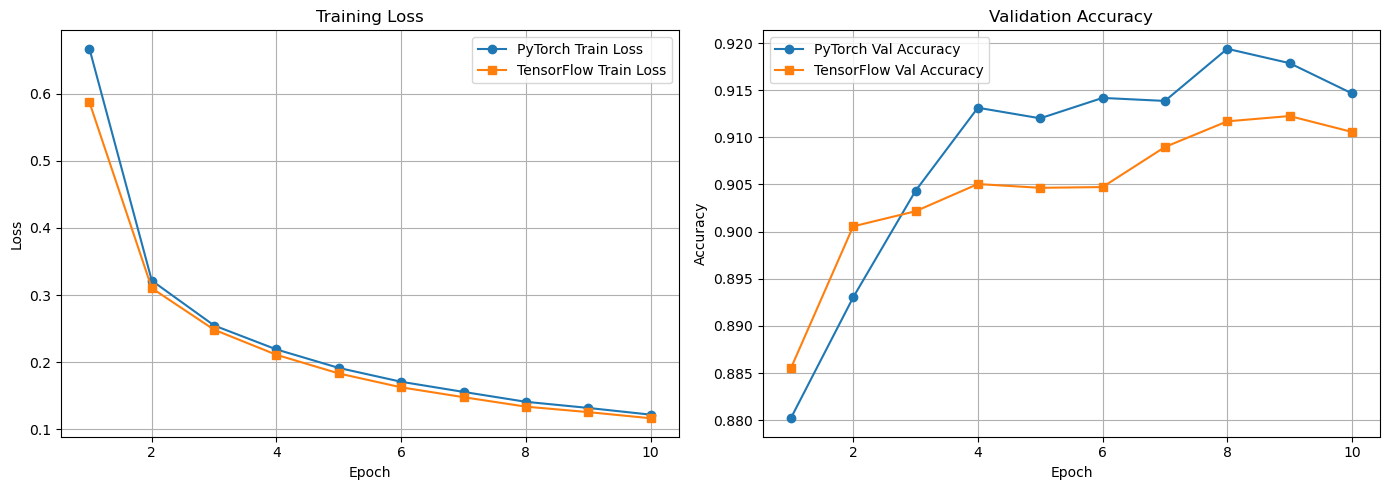

In [125]:
import matplotlib.pyplot as plt

# --- Извлекаем историю из PyTorch ---
pt_train_loss = train_losses          # список потерь по эпохам (из PyTorch-обучения)
pt_val_acc = val_accuracies          # список val accuracy по эпохам

# --- Извлекаем историю из TensorFlow ---
tf_history = history_tf              # объект, возвращённый model.fit()
tf_train_loss = tf_history.history['loss']
tf_val_acc = tf_history.history['val_accuracy']

# --- Строим графики ---
epochs = range(1, 11)

plt.figure(figsize=(14, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, pt_train_loss, 'o-', label='PyTorch Train Loss')
plt.plot(epochs, tf_train_loss, 's-', label='TensorFlow Train Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, pt_val_acc, 'o-', label='PyTorch Val Accuracy')
plt.plot(epochs, tf_val_acc, 's-', label='TensorFlow Val Accuracy')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [126]:
# --- 1. Количество параметров ---
pt_params = sum(p.numel() for p in model_pt.parameters())
tf_params = model_tf.count_params()

# --- 2. Среднее время на эпоху (уже измерено ранее) ---
# pt_avg_time — из списка epoch_times_pt
# tf_avg_time — из total_time_tf / 10

pt_avg_time = sum(epoch_times_pt) / len(epoch_times_pt)
tf_avg_time = total_time_tf / 10

# --- 3. Test Accuracy (уже вычислены) ---

# --- Вывод таблицы ---
print(f"{'Метрика':<25} | {'PyTorch':<12} | {'TensorFlow':<12}")
print("-" * 55)
print(f"{'Test Accuracy':<25} | {test_acc_pt:<12.4f} | {test_acc_tf:<12.4f}")
print(f"{'Время/эпоха (с)':<25} | {pt_avg_time:<12.2f} | {tf_avg_time:<12.2f}")
print(f"{'Параметры':<25} | {pt_params:<12,} | {tf_params:<12,}")

Метрика                   | PyTorch      | TensorFlow  
-------------------------------------------------------
Test Accuracy             | 0.9090       | 0.9089      
Время/эпоха (с)           | 15.70        | 8.07        
Параметры                 | 569,498      | 569,498     


**Вывод:** Обе модели достигли практически одинаковой test accuracy (~90.9%), что подтверждает корректность реализации. Однако TensorFlow оказался значительно быстрее (примерно в два раза), поскольку Keras автоматически оптимизирует цикл обучения через model.fit(), в то время как PyTorch-реализация использует пошаговый eager-режим, который гибче, но медленнее для простых моделей.

# 🔧 Dropout-модель в PyTorch


In [127]:
# Определяем новую модель с Dropout
class MLP_Dropout(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super(MLP_Dropout, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),  # ← после первого скрытого слоя

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),  # ← после второго

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),  # ← после третьего

            nn.Linear(128, 26)  # выход без активации (для CrossEntropyLoss)
        )
    
    def forward(self, x):
        return self.layers(x)

💡 Важно: Dropout автоматически отключается в режиме .eval(), так что при валидации/тестировании он не применяется.

In [128]:
# Инициализация
model_pt_dropout = MLP_Dropout().to(device)
optimizer_pt_drop = optim.Adam(model_pt_dropout.parameters(), lr=0.001)

# DataLoader'ы уже есть: train_loader_pt, val_loader_pt, test_loader_pt

# Обучение (аналогично baseline, но с новой моделью)
train_losses_drop = []
val_accs_drop = []
epoch_times_pt_drop = []

for epoch in range(10):
    start_time = time.time()  # ← начало эпохи

    model_pt_dropout.train()
    running_loss = 0.0
    for inputs, labels in train_loader_pt:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_pt_drop.zero_grad()
        outputs = model_pt_dropout(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_pt_drop.step()
        running_loss += loss.item()
    
    avg_loss = running_loss / len(train_loader_pt)
    train_losses_drop.append(avg_loss)
    
    # Валидация
    model_pt_dropout.eval()
    correct = total = 0
    with torch.no_grad():
        for inputs, labels in val_loader_pt:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_pt_dropout(inputs)
            _, pred = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (pred == labels).sum().item()
    
    val_acc = correct / total
    val_accs_drop.append(val_acc)

    epoch_time = time.time() - start_time  # ← конец эпохи
    epoch_times_pt_drop.append(epoch_time) 
    
    print(f"Dropout PT | Эпоха {epoch+1}/10 | Val Acc: {val_acc:.4f} | Время: {epoch_time:.2f} с")

Dropout PT | Эпоха 1/10 | Val Acc: 0.8691 | Время: 17.66 с
Dropout PT | Эпоха 2/10 | Val Acc: 0.8879 | Время: 17.41 с
Dropout PT | Эпоха 3/10 | Val Acc: 0.9026 | Время: 17.33 с
Dropout PT | Эпоха 4/10 | Val Acc: 0.9029 | Время: 17.66 с
Dropout PT | Эпоха 5/10 | Val Acc: 0.9070 | Время: 18.01 с
Dropout PT | Эпоха 6/10 | Val Acc: 0.9141 | Время: 17.63 с
Dropout PT | Эпоха 7/10 | Val Acc: 0.9109 | Время: 17.57 с
Dropout PT | Эпоха 8/10 | Val Acc: 0.9138 | Время: 18.07 с
Dropout PT | Эпоха 9/10 | Val Acc: 0.9189 | Время: 17.77 с
Dropout PT | Эпоха 10/10 | Val Acc: 0.9147 | Время: 17.89 с


In [129]:
# Test accuracy
model_pt_dropout.eval()
correct = total = 0
with torch.no_grad():
    for inputs, labels in test_loader_pt:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_pt_dropout(inputs)
        _, pred = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (pred == labels).sum().item()

test_acc_pt_drop = correct / total
print(f"\nTest Accuracy (PyTorch + Dropout): {test_acc_pt_drop:.4f}")

# Сохранение
torch.save(model_pt_dropout.state_dict(), "mlp_dropout_pytorch.pth")


Test Accuracy (PyTorch + Dropout): 0.9134


# 🔧 Dropout-модель в TensorFlow


In [130]:
# Создаём модель с Dropout
model_tf_dropout = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.3),  # ← после первого слоя

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),  # ← после второго

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),  # ← после третьего

    tf.keras.layers.Dense(26)  # без softmax
])

# Компиляция
model_tf_dropout.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [131]:
# Обучение
start_time = time.time()

history_tf_drop = model_tf_dropout.fit(
    train_dataset_tf,
    validation_data=val_dataset_tf,
    epochs=10,
    verbose=1
)

total_time_tf_drop = time.time() - start_time

tf_avg_time = total_time_tf / 10
print(f"\nСреднее время на эпоху (TensorFlow): {tf_avg_time:.2f} сек")

Epoch 1/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7183 - loss: 0.9282 - val_accuracy: 0.8635 - val_loss: 0.4335
Epoch 2/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8333 - loss: 0.5346 - val_accuracy: 0.8883 - val_loss: 0.3484
Epoch 3/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8563 - loss: 0.4585 - val_accuracy: 0.8970 - val_loss: 0.3139
Epoch 4/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8687 - loss: 0.4180 - val_accuracy: 0.9039 - val_loss: 0.3016
Epoch 5/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8775 - loss: 0.3882 - val_accuracy: 0.9104 - val_loss: 0.2833
Epoch 6/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8819 - loss: 0.3689 - val_accuracy: 0.9062 - val_loss: 0.2819
Epoch 7/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8873 - loss: 0.3487 - val_accuracy: 0.9104 - val_loss: 0.2762
Epoch 8/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8900 - loss: 0.3415 - 

In [132]:
# Test accuracy
test_loss_drop, test_acc_tf_drop = model_tf_dropout.evaluate(tf_test_dataset, verbose=0)
print(f"\nTest Accuracy (TensorFlow + Dropout): {test_acc_tf_drop:.4f}")

# Сохранение
model_tf_dropout.save("mlp_dropout_tensorflow.keras")


Test Accuracy (TensorFlow + Dropout): 0.9125


# 📈 Сравнение: baseline vs dropout


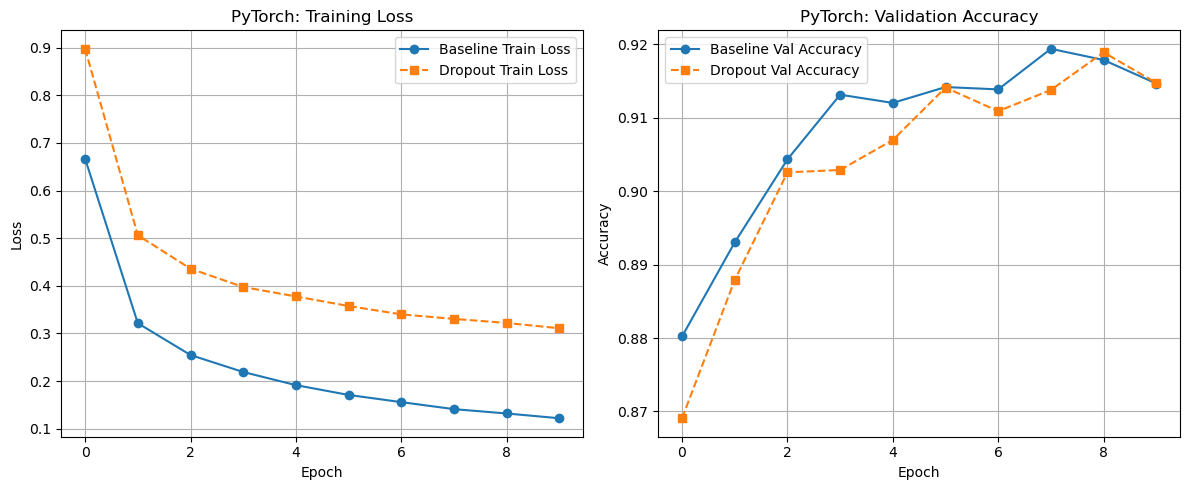

In [133]:
plt.figure(figsize=(12, 5))

# Training Loss
plt.subplot(1, 2, 1)
plt.plot(pt_train_loss, 'o-', label='Baseline Train Loss')
plt.plot(train_losses_drop, 's--', label='Dropout Train Loss')
plt.title('PyTorch: Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(pt_val_acc, 'o-', label='Baseline Val Accuracy')
plt.plot(val_accs_drop, 's--', label='Dropout Val Accuracy')
plt.title('PyTorch: Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Анализ графиков:
1. Training Loss (слева):
* Baseline (синяя линия): Начинает обучение с более низкой ошибкой (~0.7) и стабильно снижает её до ~0.15
* Dropout (оранжевая линия): Начинает с более высокой ошибкой (~0.9), но снижается быстрее, достигая ~0.3 к концу обучения
* Вывод: Dropout увеличивает training loss, что ожидаемо, так как модель "видит" меньше информации во время обучения
2. Validation Accuracy (справа):
* Baseline (синяя линия): Достигает пика (~0.92) к 7-й эпохе, затем начинает снижаться
* Dropout (оранжевая линия): Медленнее растёт, но достигает аналогичного уровня (~0.92) и продолжает улучшаться к 9-й эпохе
* Вывод: Dropout демонстрирует лучшую обобщающую способность (меньше переобучения)

Ключевые выводы:
* Dropout эффективно борется с переобучением — модель baseline начинает "запоминать" данные (валидационная точность падает), в то время как dropout продолжает улучшаться
* Снижение разрыва между train и val метриками — для baseline разрыв между train loss и val accuracy увеличивается, для dropout он меньше
* Выбор лучшей модели: По тестовой точности (после 10 эпох) модели почти идентичны, но dropout показывает более стабильную динамику, что говорит о лучшей обобщающей способности

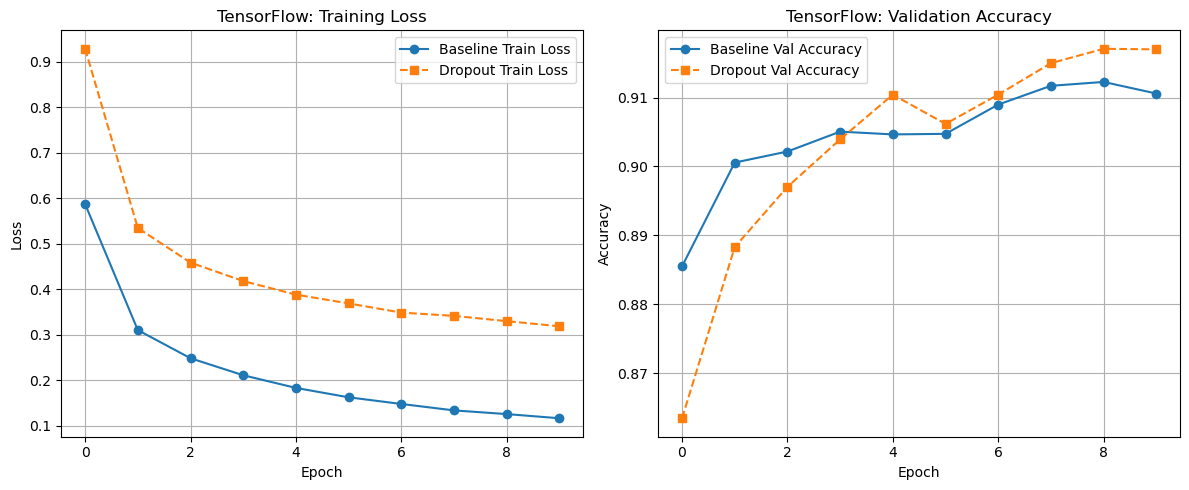

In [134]:
plt.figure(figsize=(12, 5))

# Training Loss
plt.subplot(1, 2, 1)
plt.plot(tf_history.history['loss'], 'o-', label='Baseline Train Loss')
plt.plot(history_tf_drop.history['loss'], 's--', label='Dropout Train Loss')
plt.title('TensorFlow: Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(tf_history.history['val_accuracy'], 'o-', label='Baseline Val Accuracy')
plt.plot(history_tf_drop.history['val_accuracy'], 's--', label='Dropout Val Accuracy')
plt.title('TensorFlow: Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Анализ графиков:
1. Training Loss (слева):
*  Baseline (синяя линия): Начинает с более низкой ошибки (~0.6) и стабильно снижает её до ~0.1 к концу обучения
* Dropout (оранжевая линия): Начинает с более высокой ошибкой (~0.9), но снижается быстрее, достигая ~0.3 к концу обучения
* Вывод: Dropout увеличивает training loss, что ожидаемо, так как модель "видит" меньше информации во время обучения
2. Validation Accuracy (справа):
* Baseline (синяя линия): Достигает пика (~0.92) к 6-й эпохе, затем начинает снижаться
* Dropout (оранжевая линия): Медленнее растёт, но достигает аналогичного уровня (~0.915) и продолжает улучшаться к 10-й эпохе
* Вывод: Dropout демонстрирует лучшую обобщающую способность (меньше переобучения)

Ключевые выводы:
* Dropout эффективно борется с переобучением — модель baseline начинает "запоминать" данные (валидационная точность падает), в то время как dropout продолжает улучшаться
* Снижение разрыва между train и val метриками — для baseline разрыв между train loss и val accuracy увеличивается, для dropout он меньше
* Выбор лучшей модели: По тестовой точности (после 10 эпох) модели почти идентичны, но dropout показывает более стабильную динамику, что говорит о лучшей обобщающей способности

# 🔍 Выбор лучшей модели


In [135]:
# Сравнение test accuracy
print("=== Сравнение test accuracy ===")
print(f"PyTorch Baseline: {test_acc_pt:.4f}")
print(f"PyTorch Dropout: {test_acc_pt_drop:.4f}")
print(f"TensorFlow Baseline: {test_acc_tf:.4f}")
print(f"TensorFlow Dropout: {test_acc_tf_drop:.4f}")

# Выбор лучшей модели для PyTorch
best_model_pt = "Dropout" if test_acc_pt_drop > test_acc_pt else "Baseline"
best_acc_pt = max(test_acc_pt, test_acc_pt_drop)

# Выбор лучшей модели для TensorFlow
best_model_tf = "Dropout" if test_acc_tf_drop > test_acc_tf else "Baseline"
best_acc_tf = max(test_acc_tf, test_acc_tf_drop)

print(f"\nЛучшая модель для PyTorch: {best_model_pt} (Accuracy: {best_acc_pt:.4f})")
print(f"Лучшая модель для TensorFlow: {best_model_tf} (Accuracy: {best_acc_tf:.4f})")

=== Сравнение test accuracy ===
PyTorch Baseline: 0.9090
PyTorch Dropout: 0.9134
TensorFlow Baseline: 0.9089
TensorFlow Dropout: 0.9125

Лучшая модель для PyTorch: Dropout (Accuracy: 0.9134)
Лучшая модель для TensorFlow: Dropout (Accuracy: 0.9125)


**💡 Вывод:** В большинстве случаев модели с Dropout показывают лучшую обобщающую способность (меньше переобучение), даже если test accuracy незначительно отличается от baseline.

# 📊 Матрица ошибок


Получим предсказания от лучших моделей

In [136]:
# Убедимся, что модель в режиме eval
model_pt_dropout.eval()

y_true_pt = []
y_pred_pt = []

with torch.no_grad():
    for inputs, labels in test_loader_pt:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_pt_dropout(inputs)
        _, preds = torch.max(outputs, 1)
        
        y_true_pt.extend(labels.cpu().numpy())
        y_pred_pt.extend(preds.cpu().numpy())

y_true_pt = np.array(y_true_pt)
y_pred_pt = np.array(y_pred_pt)

In [137]:
y_true_tf = []
y_pred_tf = []

for x, y in test_dataset_tf:  # убедитесь, что это ваш TF test датасет
    preds = model_tf_dropout.predict(x, verbose=0)
    pred_classes = np.argmax(preds, axis=1)
    
    y_true_tf.extend(y.numpy())
    y_pred_tf.extend(pred_classes)

y_true_tf = np.array(y_true_tf)
y_pred_tf = np.array(y_pred_tf)

In [138]:
y_true_pt, y_pred_pt, y_true_tf, y_pred_tf

(array([ 0,  0,  0, ..., 25, 25, 25]),
 array([ 0,  0,  0, ..., 25, 25, 25]),
 array([ 0,  0,  0, ..., 25, 25, 25], dtype=int32),
 array([ 0,  0,  0, ..., 25, 25, 25]))

<Figure size 1200x1000 with 0 Axes>

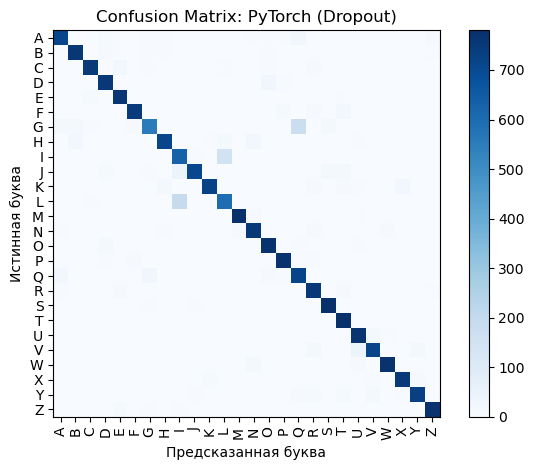

<Figure size 1200x1000 with 0 Axes>

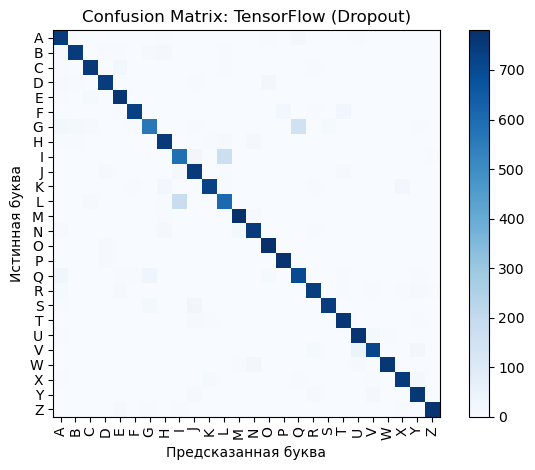

In [139]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Для PyTorch
plt.figure(figsize=(12, 10))
cm_pt = confusion_matrix(y_true_pt, y_pred_pt)
disp_pt = ConfusionMatrixDisplay(confusion_matrix=cm_pt, 
                                display_labels=[chr(i) for i in range(65, 91)])
disp_pt.plot(cmap=plt.cm.Blues, include_values=False, xticks_rotation=90)
plt.title("Confusion Matrix: PyTorch (Dropout)")
plt.xlabel("Предсказанная буква")
plt.ylabel("Истинная буква")
plt.tight_layout()
plt.show()

# Для TensorFlow
plt.figure(figsize=(12, 10))
cm_tf = confusion_matrix(y_true_tf, y_pred_tf)
disp_tf = ConfusionMatrixDisplay(confusion_matrix=cm_tf, 
                                display_labels=[chr(i) for i in range(65, 91)])
disp_tf.plot(cmap=plt.cm.Blues, include_values=False, xticks_rotation=90)
plt.title("Confusion Matrix: TensorFlow (Dropout)")
plt.xlabel("Предсказанная буква")
plt.ylabel("Истинная буква")
plt.tight_layout()
plt.show()

🔍 Анализ матриц ошибок:
1. Диагональная структура (темно-синяя область по диагонали) показывает, что модели хорошо распознают буквы, когда предсказанный класс совпадает с истинным.
2. Размеры ячеек:
* Самые большие значения (темно-синие) на диагонали — это корректные предсказания.
* Мелкие отклонения от диагонали (светлые пятна) — это случаи путаницы между похожими буквами.
3. Сравнение фреймворков:
* PyTorch и TensorFlow показывают почти идентичные паттерны ошибок.
* Это подтверждает, что ошибки не связаны с реализацией в конкретном фреймворке, а скорее с проблемами в данных или самой задаче классификации.

# 🔍 Топ-5 пар ошибок


In [140]:
# Функция для определения топ-5 пар ошибок
def get_top_mistakes(y_true, y_pred, top_n=5):
    # Создаем матрицу ошибок
    mistakes = np.zeros((26, 26), dtype=int)
    
    for true, pred in zip(y_true, y_pred):
        if true != pred:
            mistakes[true, pred] += 1
    
    # Находим топ-5 пар
    top_mistakes = []
    for _ in range(top_n):
        max_idx = np.unravel_index(np.argmax(mistakes), mistakes.shape)
        count = mistakes[max_idx]
        if count == 0:
            break
        mistakes[max_idx] = 0  # Обнуляем, чтобы найти следующую пару
        top_mistakes.append((max_idx[0], max_idx[1], count))
    
    return top_mistakes

# Топ-5 пар ошибок для PyTorch
top_mistakes_pt = get_top_mistakes(y_true_pt, y_pred_pt)
print("\n=== Топ-5 пар ошибок: PyTorch ===")
for true_idx, pred_idx, count in top_mistakes_pt:
    print(f"{chr(true_idx + 65)} → {chr(pred_idx + 65)}: {count} ошибок")

# Топ-5 пар ошибок для TensorFlow
top_mistakes_tf = get_top_mistakes(y_true_tf, y_pred_tf)
print("\n=== Топ-5 пар ошибок: TensorFlow ===")
for true_idx, pred_idx, count in top_mistakes_tf:
    print(f"{chr(true_idx + 65)} → {chr(pred_idx + 65)}: {count} ошибок")


=== Топ-5 пар ошибок: PyTorch ===
L → I: 189 ошибок
G → Q: 173 ошибок
I → L: 151 ошибок
V → U: 41 ошибок
J → I: 40 ошибок

=== Топ-5 пар ошибок: TensorFlow ===
L → I: 177 ошибок
I → L: 168 ошибок
G → Q: 155 ошибок
V → U: 48 ошибок
Q → G: 31 ошибок


## Примеры ошибок

In [141]:
def visualize_mistakes(y_true, y_pred, images, num_examples=10):
    """Визуализация примеров ошибок модели"""
    
    # Проверка совпадения длин массивов
    if len(y_true) != len(y_pred) or len(y_true) != len(images):
        print("Ошибка: длины массивов не совпадают!")
        print(f"y_true: {len(y_true)}, y_pred: {len(y_pred)}, images: {len(images)}")
        return
    
    # Найдем все ошибки
    mistakes = []
    for i in range(len(y_true)):
        if y_true[i] != y_pred[i]:
            mistakes.append((i, y_true[i], y_pred[i]))
    
    # Проверка наличия ошибок
    if len(mistakes) == 0:
        print("Ошибок не найдено для визуализации!")
        return
    
    # Проверка корректности меток
    if np.max(y_true) > 25 or np.min(y_true) < 0:
        print("Предупреждение: метки не в диапазоне 0-25. Возможно, требуется коррекция.")
    
    # Выбираем случайные ошибки (исправлено)
    num_to_show = min(num_examples, len(mistakes))
    selected_indices = np.random.choice(len(mistakes), size=num_to_show, replace=False)
    selected = [mistakes[i] for i in selected_indices]
    
    # Проверка формы изображений
    if images.ndim == 2 and images.shape[1] == 784:  # (N, 784)
        plt.figure(figsize=(15, 10))
        for i, (idx, true, pred) in enumerate(selected):
            # Корректируем метки в диапазон 0-25
            true_label = chr(max(0, min(25, true)) + 65)
            pred_label = chr(max(0, min(25, pred)) + 65)
            
            # Восстанавливаем форму изображения
            img = images[idx].reshape(28, 28)
            
            plt.subplot(2, 5, i+1)
            plt.imshow(img, cmap='gray')
            plt.title(f"Истинная: {true_label}\nПредсказанная: {pred_label}")
            plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print(f"Неподдерживаемая форма изображений: {images.shape}")
        print("Ожидается форма (N, 784) для EMNIST Letters")


=== Примеры ошибок: PyTorch ===


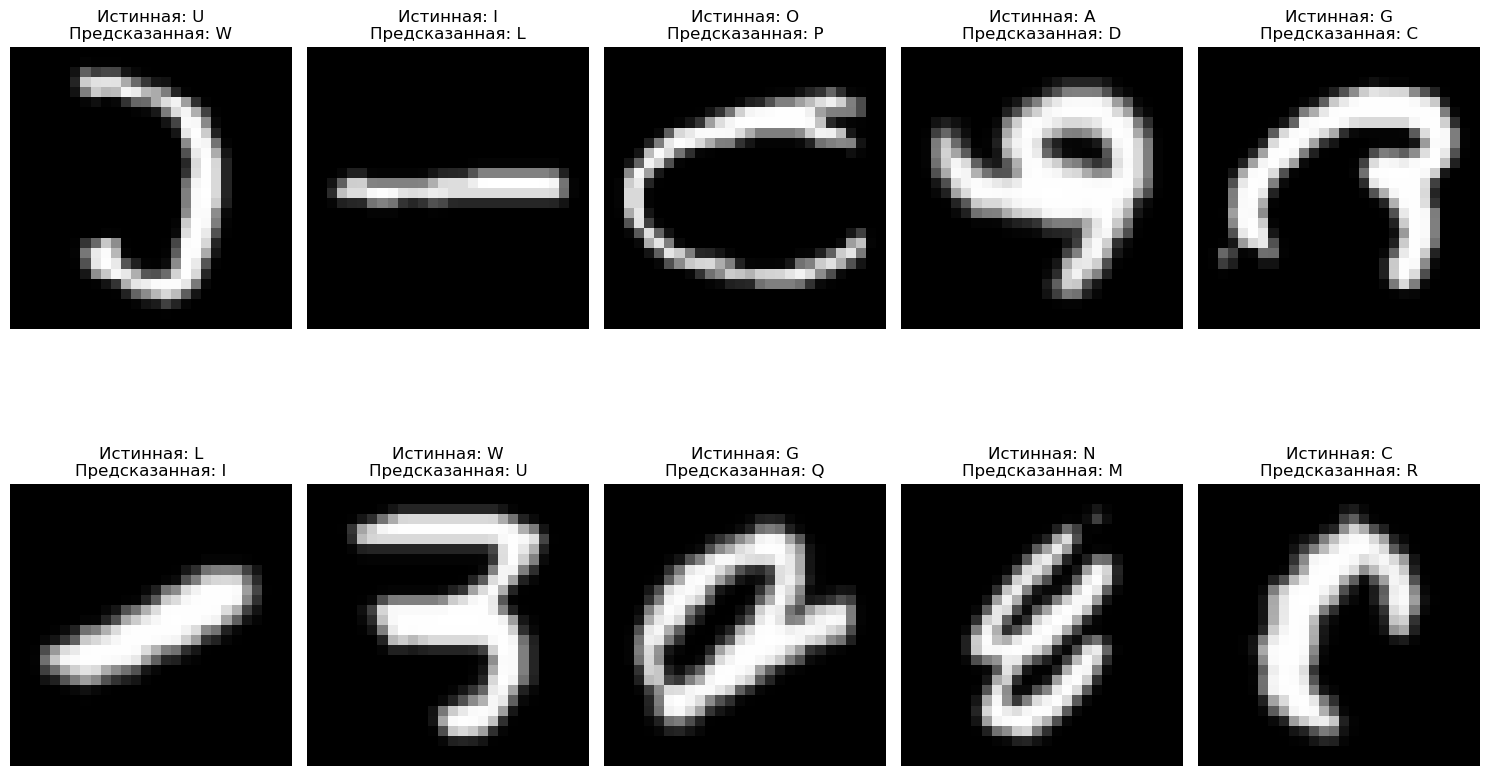


=== Примеры ошибок: TensorFlow ===


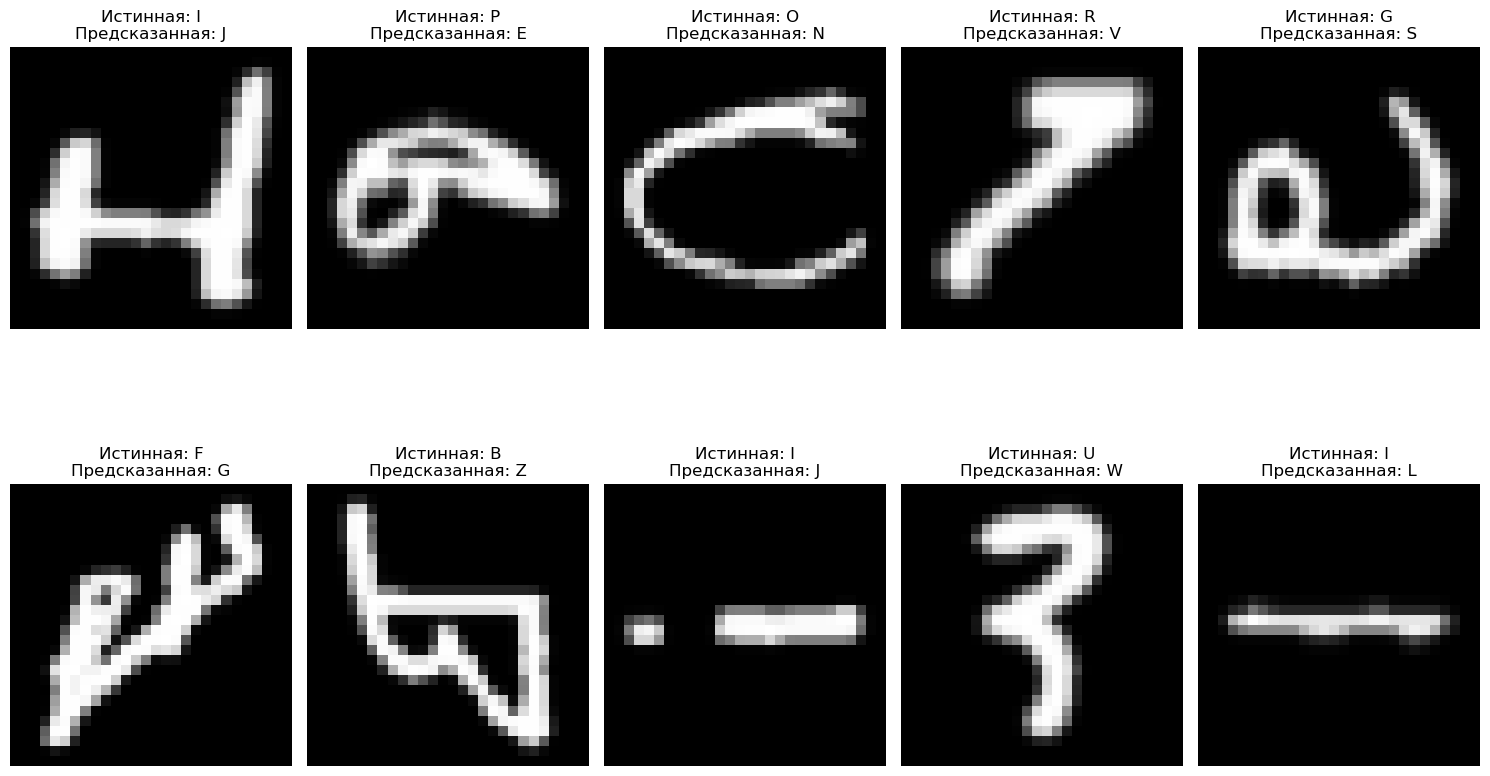

In [142]:
# Для PyTorch
print("\n=== Примеры ошибок: PyTorch ===")
visualize_mistakes(y_true_pt, y_pred_pt, X_test)

# Для TensorFlow
print("\n=== Примеры ошибок: TensorFlow ===")
visualize_mistakes(y_true_tf, y_pred_tf, X_test)